# Machine Learning-Based PCOS Prediction

This Google Colab notebook develops and compares three machine learning classification models for predicting Polycystic Ovary Syndrome (PCOS):

1. Logistic Regression
2. Random Forest
3. Support Vector Machine (SVM)

The notebook uses the uploaded MenstraCare/PCOS dataset and applies a common data cleaning and preprocessing strategy to all three models.

### Evaluation metrics
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix
- ROC Curve

> **Research note:** All available predictor columns are retained initially, as planned. Potential data leakage, diagnostic overlap, and feature redundancy should be discussed separately before finalizing the research methodology.

## 1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Upload Dataset Using the Colab GUI

Run the next cell and click **Choose Files**.

Select the Excel (`.xlsx`/`.xls`) or CSV dataset from your computer.

No file path or Google Drive path is required.

In [ ]:
uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("No file was uploaded.")

file_name = list(uploaded.keys())[0]

print("Selected file:", file_name)

Saving MenstraCare_TrainingData_Modified.xlsx to MenstraCare_TrainingData_Modified.xlsx
Selected file: MenstraCare_TrainingData_Modified.xlsx


In [ ]:
import io

if file_name.lower().endswith((".xlsx", ".xls")):
    excel_file = pd.ExcelFile(io.BytesIO(uploaded[file_name]))

    print("Excel sheets found:")
    for i, sheet in enumerate(excel_file.sheet_names, start=1):
        print(f"{i}. {sheet}")

    # The uploaded dataset contains one worksheet, so use the first sheet.
    df = pd.read_excel(
        io.BytesIO(uploaded[file_name]),
        sheet_name=excel_file.sheet_names[0]
    )

elif file_name.lower().endswith(".csv"):
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))

else:
    raise ValueError(
        "Unsupported file type. Please upload an Excel (.xlsx/.xls) or CSV (.csv) file."
    )

print("\nDataset loaded successfully.")
print("Dataset shape:", df.shape)

Excel sheets found:
1. PCOS_data.csv

Dataset loaded successfully.
Dataset shape: (541, 32)


## 3. Initial Dataset Inspection

The dataset is inspected before cleaning to understand its dimensions, columns, data types, missing values, and duplicate records.

In [ ]:
display(df.head())

,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),Hb(g/dl),Cycle(R/I),Cycle length(days),Pregnant(Y/N),No. of abortions,FSH(mIU/mL),LH(mIU/mL),FSH/LH,TSH (mIU/L),AMH(ng/mL),PRL(ng/mL),PRG(ng/mL),RBS(mg/dl),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 31
0,0,28,44.6,152.0,10.48,2,5,0,0,7.95,3.68,2.16,0.68,2.07,45.16,0.57,92.0,0,0,0,0,0,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,0,36,65.0,161.5,11.70,2,5,1,0,6.73,1.09,6.17,3.16,1.53,20.09,0.97,92.0,0,0,0,0,0,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,1,33,68.8,165.0,11.80,2,5,1,0,5.54,0.88,6.30,2.54,6.63,10.52,0.36,84.0,0,0,0,1,1,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,0,37,65.0,148.0,12.00,2,5,0,0,8.06,2.36,3.42,16.41,1.22,36.90,0.36,76.0,0,0,0,0,0,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,0,25,52.0,161.0,10.00,2,5,1,0,3.98,0.90,4.42,3.57,2.26,30.09,0.38,84.0,0,0,0,1,0,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 541
Number of columns: 32


In [ ]:
print("Column names:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}: {column}")

Column names:

1: PCOS (Y/N)
2: Age (yrs)
3: Weight (Kg)
4: Height(Cm)
5: Hb(g/dl)
6: Cycle(R/I)
7: Cycle length(days)
8: Pregnant(Y/N)
9: No. of abortions
10: FSH(mIU/mL)
11: LH(mIU/mL)
12: FSH/LH
13: TSH (mIU/L)
14: AMH(ng/mL)
15: PRL(ng/mL)
16: PRG(ng/mL)
17: RBS(mg/dl)
18: Weight gain(Y/N)
19: hair growth(Y/N)
20: Skin darkening (Y/N)
21: Hair loss(Y/N)
22: Pimples(Y/N)
23: Fast food (Y/N)
24: Reg.Exercise(Y/N)
25: BP _Systolic (mmHg)
26: BP _Diastolic (mmHg)
27: Follicle No. (L)
28: Follicle No. (R)
29: Avg. F size (L) (mm)
30: Avg. F size (R) (mm)
31: Endometrium (mm)
32: Unnamed: 31


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PCOS (Y/N)            541 non-null    int64  
 1   Age (yrs)             541 non-null    int64  
 2   Weight (Kg)           541 non-null    float64
 3   Height(Cm)            541 non-null    float64
 4   Hb(g/dl)              541 non-null    float64
 5   Cycle(R/I)            541 non-null    int64  
 6   Cycle length(days)    541 non-null    int64  
 7   Pregnant(Y/N)         541 non-null    int64  
 8   No. of abortions      541 non-null    int64  
 9   FSH(mIU/mL)           541 non-null    float64
 10  LH(mIU/mL)            541 non-null    float64
 11  FSH/LH                541 non-null    float64
 12  TSH (mIU/L)           541 non-null    float64
 13  AMH(ng/mL)            541 non-null    object 
 14  PRL(ng/mL)            541 non-null    float64
 15  PRG(ng/mL)            5

In [ ]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PCOS (Y/N),541.0,NaN,NaN,NaN,0.327172,0.469615,0.0,0.0,0.0,1.0,1.0
Age (yrs),541.0,NaN,NaN,NaN,31.430684,5.411006,20.0,28.0,31.0,35.0,48.0
Weight (Kg),541.0,NaN,NaN,NaN,59.637153,11.028287,31.0,52.0,59.0,65.0,108.0
Height(Cm),541.0,NaN,NaN,NaN,156.484835,6.033545,137.0,152.0,156.0,160.0,180.0
Hb(g/dl),541.0,NaN,NaN,NaN,11.160037,0.866904,8.5,10.5,11.0,11.7,14.8
Cycle(R/I),541.0,NaN,NaN,NaN,2.560074,0.90195,2.0,2.0,2.0,4.0,5.0
Cycle length(days),541.0,NaN,NaN,NaN,4.94085,1.49202,0.0,4.0,5.0,5.0,12.0
Pregnant(Y/N),541.0,NaN,NaN,NaN,0.380776,0.486027,0.0,0.0,0.0,1.0,1.0
No. of abortions,541.0,NaN,NaN,NaN,0.288355,0.692575,0.0,0.0,0.0,0.0,5.0
FSH(mIU/mL),541.0,NaN,NaN,NaN,14.601832,217.022081,0.21,3.3,4.85,6.41,5052.0


In [ ]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Columns containing missing values:")
display(missing_values)

Columns containing missing values:


,0
Unnamed: 31,539
Fast food (Y/N),1


In [ ]:
print("Number of exact duplicate rows:", df.duplicated().sum())

Number of exact duplicate rows: 0


## 4. Data Cleaning

The uploaded dataset was inspected and contains an extra unnamed column and a few values that may be stored as text even though the variables are numerical.

The cleaning procedure will:

- Remove unnamed/empty columns.
- Clean column names for easier programming.
- Convert predictor columns to numeric values where appropriate.
- Convert invalid numeric entries into missing values (`NaN`).
- Remove rows with missing target values.
- Remove exact duplicate rows.
- Keep all meaningful predictor variables for the initial modelling experiment.

In [ ]:
# Remove unnamed columns
df = df.loc[:, ~df.columns.astype(str).str.strip().str.lower().str.startswith("unnamed")]

print("Shape after removing unnamed columns:", df.shape)

Shape after removing unnamed columns: (541, 31)


In [ ]:
# Clean column names
df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.replace(" ", "_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("/", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

print("Cleaned column names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}: {column}")

Cleaned column names:
1: PCOS_Y_N
2: Age_yrs
3: Weight_Kg
4: HeightCm
5: Hbg_dl
6: CycleR_I
7: Cycle_lengthdays
8: PregnantY_N
9: No._of_abortions
10: FSHmIU_mL
11: LHmIU_mL
12: FSH_LH
13: TSH_mIU_L
14: AMHng_mL
15: PRLng_mL
16: PRGng_mL
17: RBSmg_dl
18: Weight_gainY_N
19: hair_growthY_N
20: Skin_darkening_Y_N
21: Hair_lossY_N
22: PimplesY_N
23: Fast_food_Y_N
24: Reg.ExerciseY_N
25: BP__Systolic_mmHg
26: BP__Diastolic_mmHg
27: Follicle_No._L
28: Follicle_No._R
29: Avg._F_size_L_mm
30: Avg._F_size_R_mm
31: Endometrium_mm


In [ ]:
# Verify the target column
TARGET = "PCOS_Y_N"

if TARGET not in df.columns:
    raise KeyError(
        f"Target column '{TARGET}' was not found. "
        f"Available columns are: {df.columns.tolist()}"
    )

print("Target column found:", TARGET)
print("\nTarget values before conversion:")
print(df[TARGET].value_counts(dropna=False))

Target column found: PCOS_Y_N

Target values before conversion:
PCOS_Y_N
0    364
1    177
Name: count, dtype: int64


In [ ]:
# Convert target to numeric binary values.
# The original dataset already uses 0/1, but this also handles Y/N if encountered.

target_mapping = {
    "Y": 1,
    "N": 0,
    "YES": 1,
    "NO": 0,
    "1": 1,
    "0": 0
}

if df[TARGET].dtype == "object":
    df[TARGET] = (
        df[TARGET]
        .astype(str)
        .str.strip()
        .str.upper()
        .map(target_mapping)
    )
else:
    df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")

print("Target values after conversion:")
print(df[TARGET].value_counts(dropna=False))

Target values after conversion:
PCOS_Y_N
0    364
1    177
Name: count, dtype: int64


In [ ]:
# Convert all predictor columns to numeric where possible.
# This is appropriate for this dataset because its Yes/No and categorical
# clinical variables are represented as numerical codes.

feature_columns = [c for c in df.columns if c != TARGET]

for column in feature_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

print("Predictor data types after conversion:")
display(df[feature_columns].dtypes.to_frame("dtype"))

Predictor data types after conversion:


,dtype
Age_yrs,int64
Weight_Kg,float64
HeightCm,float64
Hbg_dl,float64
CycleR_I,int64
Cycle_lengthdays,int64
PregnantY_N,int64
No._of_abortions,int64
FSHmIU_mL,float64
LHmIU_mL,float64


In [ ]:
# Remove rows with missing target values
missing_target = df[TARGET].isna().sum()

print("Missing target values:", missing_target)

if missing_target > 0:
    df = df.dropna(subset=[TARGET]).reset_index(drop=True)

print("Dataset shape after target cleaning:", df.shape)

Missing target values: 0
Dataset shape after target cleaning: (541, 31)


In [ ]:
# Remove exact duplicate rows
duplicate_count = df.duplicated().sum()

print("Duplicate rows before removal:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)

print("Final shape after duplicate removal:", df.shape)

Duplicate rows before removal: 0
Final shape after duplicate removal: (541, 31)


## 5. Missing-Value Analysis After Cleaning

Missing predictor values are not removed from the dataset. Instead, they will be handled inside the machine learning preprocessing pipeline using median imputation.

This prevents unnecessary loss of patient records and ensures that imputation parameters are learned only from the training data.

In [ ]:
missing_after_cleaning = df.isnull().sum()
missing_after_cleaning = missing_after_cleaning[missing_after_cleaning > 0].sort_values(ascending=False)

if len(missing_after_cleaning) == 0:
    print("No missing predictor values remain.")
else:
    display(missing_after_cleaning.to_frame("Missing Values"))

,Missing Values
AMHng_mL,1
Fast_food_Y_N,1


## 6. Separate Features and Target

The target variable is `PCOS_Y_N`:

- `0` = No PCOS
- `1` = PCOS

All remaining meaningful columns are initially retained as predictors.

In [ ]:
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (541, 30)
Target vector shape: (541,)


In [ ]:
print("PCOS class distribution:")
display(y.value_counts().rename(index={0: "No PCOS", 1: "PCOS"}))

print("\nPCOS class percentage:")
display((y.value_counts(normalize=True) * 100).round(2).rename(index={0: "No PCOS", 1: "PCOS"}))

PCOS class distribution:


,count
PCOS_Y_N,
No PCOS,364
PCOS,177



PCOS class percentage:


,proportion
PCOS_Y_N,
No PCOS,67.28
PCOS,32.72


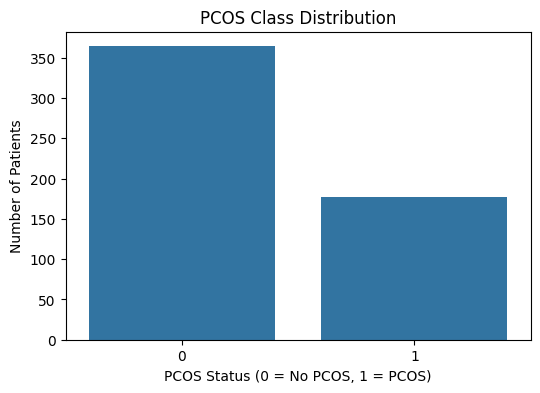

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(x=y)

plt.title("PCOS Class Distribution")
plt.xlabel("PCOS Status (0 = No PCOS, 1 = PCOS)")
plt.ylabel("Number of Patients")

plt.show()

## 7. Identify Numerical and Categorical Features

The uploaded dataset uses numerical coding for the clinical binary/categorical variables, so most or all predictors are expected to be numerical after cleaning.

The code below detects the actual data types automatically.

In [ ]:
numeric_features = X.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 30
Number of categorical features: 0

Numerical features:
['Age_yrs', 'Weight_Kg', 'HeightCm', 'Hbg_dl', 'CycleR_I', 'Cycle_lengthdays', 'PregnantY_N', 'No._of_abortions', 'FSHmIU_mL', 'LHmIU_mL', 'FSH_LH', 'TSH_mIU_L', 'AMHng_mL', 'PRLng_mL', 'PRGng_mL', 'RBSmg_dl', 'Weight_gainY_N', 'hair_growthY_N', 'Skin_darkening_Y_N', 'Hair_lossY_N', 'PimplesY_N', 'Fast_food_Y_N', 'Reg.ExerciseY_N', 'BP__Systolic_mmHg', 'BP__Diastolic_mmHg', 'Follicle_No._L', 'Follicle_No._R', 'Avg._F_size_L_mm', 'Avg._F_size_R_mm', 'Endometrium_mm']

Categorical features:
[]


## 8. Train-Test Split

The data is divided into:

- 80% training data
- 20% testing data

Stratification preserves the PCOS/non-PCOS class distribution in both subsets.

The same split is used for all three models so their performance can be compared fairly.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining class distribution:")
display(y_train.value_counts(normalize=True).rename(index={0: "No PCOS", 1: "PCOS"}))

print("\nTesting class distribution:")
display(y_test.value_counts(normalize=True).rename(index={0: "No PCOS", 1: "PCOS"}))

Training set shape: (432, 30)
Testing set shape: (109, 30)

Training class distribution:


,proportion
PCOS_Y_N,
No PCOS,0.673611
PCOS,0.326389



Testing class distribution:


,proportion
PCOS_Y_N,
No PCOS,0.669725
PCOS,0.330275


## 9. Common Data Preprocessing Pipeline

The same preprocessing strategy is used for Logistic Regression, Random Forest, and SVM.

### Numerical features
- Missing values → median imputation
- Standardization → StandardScaler

### Categorical features
- Missing values → most frequent category
- One-hot encoding → categorical representation

The preprocessing is placed inside each model pipeline. Therefore, the preprocessing parameters are learned only from the training data, reducing the risk of test-set leakage.

In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Common preprocessing pipeline created successfully.")

Common preprocessing pipeline created successfully.


# 10. Logistic Regression

Logistic Regression is used as the baseline classification model.

It estimates the probability of PCOS and provides an interpretable baseline against which the nonlinear models can be compared.

In [ ]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [ ]:
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, zero_division=0)
lr_recall = recall_score(y_test, y_pred_lr, zero_division=0)
lr_f1 = f1_score(y_test, y_pred_lr, zero_division=0)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy  : {lr_accuracy:.4f}")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1 Score  : {lr_f1:.4f}")
print(f"ROC-AUC   : {lr_auc:.4f}")

Logistic Regression Performance
--------------------------------
Accuracy  : 0.8899
Precision : 0.7857
Recall    : 0.9167
F1 Score  : 0.8462
ROC-AUC   : 0.9521


In [ ]:
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["No PCOS", "PCOS"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     No PCOS       0.96      0.88      0.91        73
        PCOS       0.79      0.92      0.85        36

    accuracy                           0.89       109
   macro avg       0.87      0.90      0.88       109
weighted avg       0.90      0.89      0.89       109



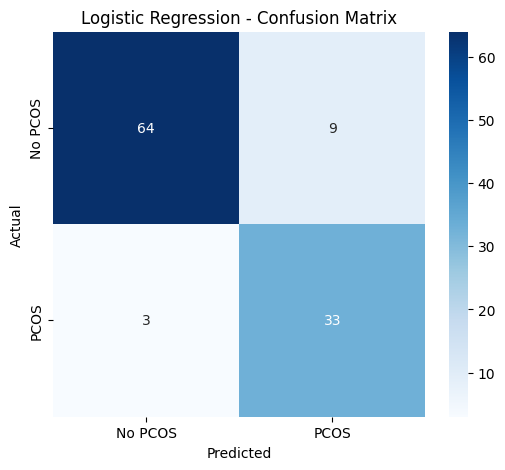

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No PCOS", "PCOS"],
    yticklabels=["No PCOS", "PCOS"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 11. Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

It can model nonlinear relationships and interactions among clinical, hormonal, lifestyle, symptomatic, and ultrasonographic predictors.

In [ ]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [ ]:
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, zero_division=0)
rf_recall = recall_score(y_test, y_pred_rf, zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, zero_division=0)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_auc:.4f}")

Random Forest Performance
-------------------------
Accuracy  : 0.9358
Precision : 0.9677
Recall    : 0.8333
F1 Score  : 0.8955
ROC-AUC   : 0.9446


In [ ]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["No PCOS", "PCOS"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     No PCOS       0.92      0.99      0.95        73
        PCOS       0.97      0.83      0.90        36

    accuracy                           0.94       109
   macro avg       0.95      0.91      0.92       109
weighted avg       0.94      0.94      0.93       109



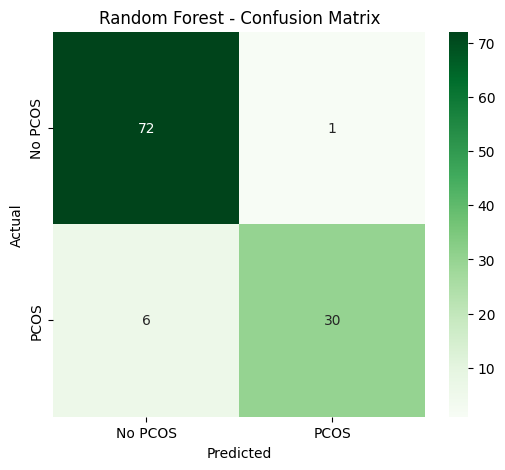

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No PCOS", "PCOS"],
    yticklabels=["No PCOS", "PCOS"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 12. Support Vector Machine (SVM)

Support Vector Machine is used as the third classification model.

An RBF (Radial Basis Function) kernel is used to capture nonlinear relationships between predictors and PCOS status.

Feature scaling is especially important for SVM and is therefore included in the common preprocessing pipeline.

In [ ]:
svm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

svm_model.fit(X_train, y_train)

print("SVM training completed.")

SVM training completed.


In [ ]:
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm, zero_division=0)
svm_recall = recall_score(y_test, y_pred_svm, zero_division=0)
svm_f1 = f1_score(y_test, y_pred_svm, zero_division=0)
svm_auc = roc_auc_score(y_test, y_prob_svm)

print("Support Vector Machine Performance")
print("----------------------------------")
print(f"Accuracy  : {svm_accuracy:.4f}")
print(f"Precision : {svm_precision:.4f}")
print(f"Recall    : {svm_recall:.4f}")
print(f"F1 Score  : {svm_f1:.4f}")
print(f"ROC-AUC   : {svm_auc:.4f}")

Support Vector Machine Performance
----------------------------------
Accuracy  : 0.9266
Precision : 0.8684
Recall    : 0.9167
F1 Score  : 0.8919
ROC-AUC   : 0.9541


In [ ]:
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=["No PCOS", "PCOS"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     No PCOS       0.96      0.93      0.94        73
        PCOS       0.87      0.92      0.89        36

    accuracy                           0.93       109
   macro avg       0.91      0.92      0.92       109
weighted avg       0.93      0.93      0.93       109



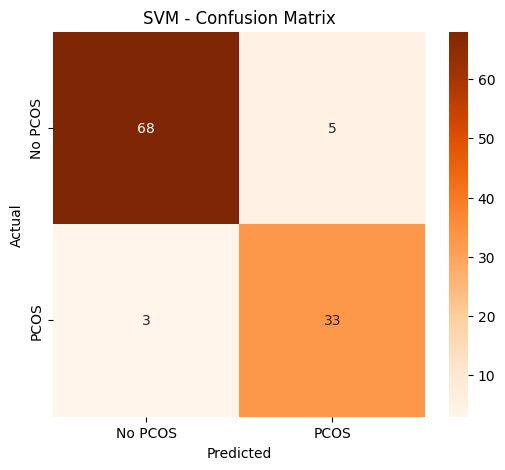

In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No PCOS", "PCOS"],
    yticklabels=["No PCOS", "PCOS"]
)

plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 13. Comparison of the Three Models

The three models are compared using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Accuracy is not considered alone because class imbalance can make accuracy misleading. Recall, F1-score, and ROC-AUC are also important for PCOS classification.

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Support Vector Machine"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        svm_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision,
        svm_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall,
        svm_recall
    ],
    "F1 Score": [
        lr_f1,
        rf_f1,
        svm_f1
    ],
    "ROC-AUC": [
        lr_auc,
        rf_auc,
        svm_auc
    ]
})

results = results.round(4)

display(results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8899,0.7857,0.9167,0.8462,0.9521
1,Random Forest,0.9358,0.9677,0.8333,0.8955,0.9446
2,Support Vector Machine,0.9266,0.8684,0.9167,0.8919,0.9541


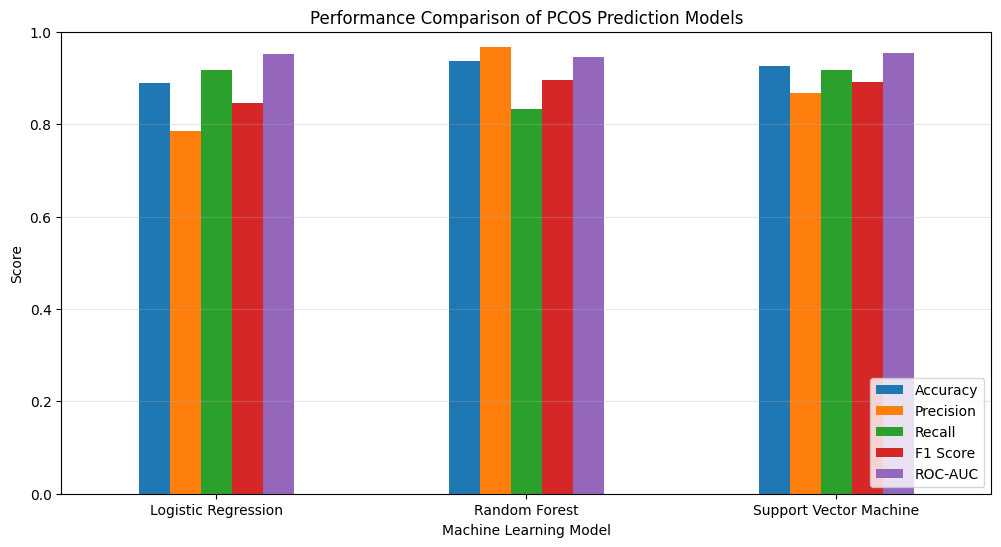

In [ ]:
plot_data = results.set_index("Model")

ax = plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Performance Comparison of PCOS Prediction Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)

plt.show()

# 14. ROC Curve Comparison

ROC curves compare the ability of the three models to distinguish PCOS from non-PCOS cases across different classification thresholds.

The Area Under the ROC Curve (ROC-AUC) provides a summary measure of discriminative performance.

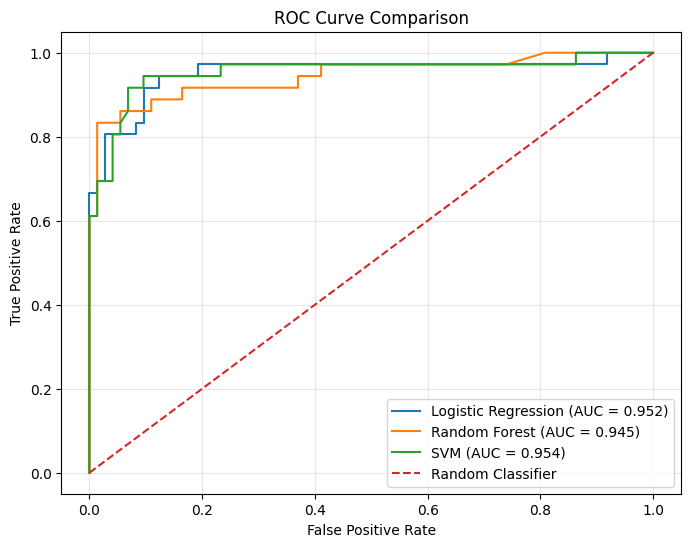

In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f"SVM (AUC = {svm_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# 15. Random Forest Feature Importance

Random Forest feature importance is used to identify which predictors contribute most strongly to the model.

This analysis is exploratory. Feature importance does not by itself establish a causal relationship between a predictor and PCOS.

In [ ]:
rf_preprocessor = random_forest_model.named_steps["preprocessor"]

feature_names = rf_preprocessor.get_feature_names_out()

importances = (
    random_forest_model
    .named_steps["classifier"]
    .feature_importances_
)

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance_df.head(20))

,Feature,Importance
26,num__Follicle_No._R,0.192997
25,num__Follicle_No._L,0.150366
18,num__Skin_darkening_Y_N,0.060235
17,num__hair_growthY_N,0.058595
16,num__Weight_gainY_N,0.055688
12,num__AMHng_mL,0.039379
5,num__Cycle_lengthdays,0.031664
1,num__Weight_Kg,0.030976
21,num__Fast_food_Y_N,0.027776
10,num__FSH_LH,0.026348


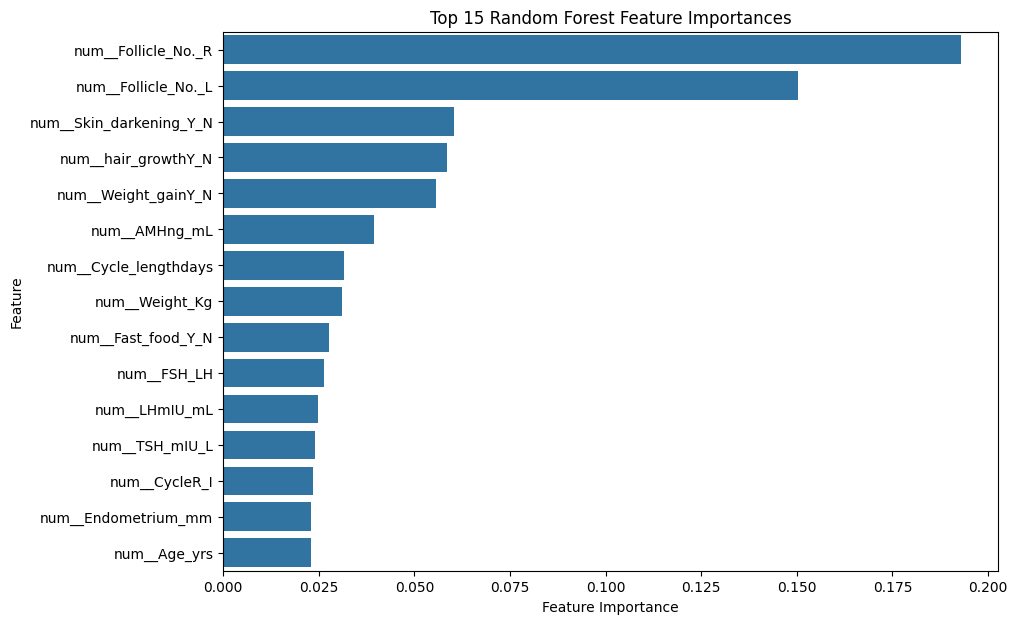

In [ ]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

# 16. Best Performing Model

The model with the highest ROC-AUC is identified below.

The final research interpretation should consider all metrics rather than selecting a model based on ROC-AUC alone.

In [ ]:
best_model = results.loc[results["ROC-AUC"].idxmax()]

print("Best model based on ROC-AUC")
print("---------------------------")

for column in best_model.index:
    print(f"{column}: {best_model[column]}")

Best model based on ROC-AUC
---------------------------
Model: Support Vector Machine
Accuracy: 0.9266
Precision: 0.8684
Recall: 0.9167
F1 Score: 0.8919
ROC-AUC: 0.9541


# 17. Final Results Summary

The three baseline machine learning models were trained using the same dataset, the same train-test split, and a common preprocessing strategy.

The results provide a baseline comparison of Logistic Regression, Random Forest, and Support Vector Machine for PCOS classification.

### Important research consideration

All available predictors were retained for this initial experiment. Before using these results in the final research paper, investigate:

- Whether ultrasound variables were used in determining the PCOS label.
- Whether hormonal variables were part of the diagnostic process.
- Whether derived variables such as FSH/LH duplicate information from FSH and LH.
- Whether any variables would be unavailable at the intended prediction time.
- Whether feature selection or ablation experiments change the model performance.

A particularly useful follow-up experiment is to compare models using:
1. Clinical/symptom/lifestyle features only.
2. Clinical + hormonal features.
3. Clinical + hormonal + ultrasound features.

This can help distinguish generalizable prediction from performance driven by diagnosis-proximal variables.

# 18. Save Model Comparison Results

The comparison table can be saved as a CSV file for use in the research paper.

In [ ]:
results.to_csv(
    "PCOS_model_comparison.csv",
    index=False
)

print("Saved: PCOS_model_comparison.csv")

Saved: PCOS_model_comparison.csv


# 19. Save Trained Models

The three trained machine learning pipelines are saved for deployment in the interactive web application.

Each saved pipeline contains:
- Data preprocessing
- Missing-value handling
- Feature scaling
- Feature encoding
- Trained machine learning model

This allows the web application to load the trained models directly and make predictions without retraining them.

In [ ]:
import os
import json
import joblib

SAVE_DIR = "/content/saved_models"

os.makedirs(SAVE_DIR, exist_ok=True)

print("Folder created:", SAVE_DIR)

Folder created: /content/saved_models


In [ ]:
joblib.dump(
    logistic_model,
    os.path.join(SAVE_DIR, "logistic_model.joblib")
)

joblib.dump(
    random_forest_model,
    os.path.join(SAVE_DIR, "random_forest_model.joblib")
)

joblib.dump(
    svm_model,
    os.path.join(SAVE_DIR, "svm_model.joblib")
)

print("Three models saved successfully.")

Three models saved successfully.


In [ ]:
feature_columns = X.columns.tolist()

with open(
    os.path.join(SAVE_DIR, "feature_columns.json"),
    "w"
) as f:
    json.dump(feature_columns, f, indent=4)

feature_info = {
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "all_features": feature_columns
}

with open(
    os.path.join(SAVE_DIR, "feature_info.json"),
    "w"
) as f:
    json.dump(feature_info, f, indent=4)

print("Feature information saved successfully.")

Feature information saved successfully.


In [ ]:
target_info = {
    "target_column": TARGET,
    "class_mapping": {
        "0": "No PCOS",
        "1": "PCOS"
    }
}

with open(
    os.path.join(SAVE_DIR, "target_info.json"),
    "w"
) as f:
    json.dump(target_info, f, indent=4)

print("Target information saved successfully.")

Target information saved successfully.


In [ ]:
deployment_config = {
    "project": "MenstraCare",
    "target_column": TARGET,
    "models": {
        "logistic_regression": "logistic_model.joblib",
        "random_forest": "random_forest_model.joblib",
        "svm": "svm_model.joblib"
    },
    "class_mapping": {
        "0": "No PCOS",
        "1": "PCOS"
    },
    "preprocessing": {
        "numeric": {
            "missing_values": "median",
            "scaling": "StandardScaler"
        },
        "categorical": {
            "missing_values": "most_frequent",
            "encoding": "OneHotEncoder",
            "handle_unknown": "ignore"
        }
    },
    "features": {
        "numeric": numeric_features,
        "categorical": categorical_features,
        "all": feature_columns
    }
}

with open(
    os.path.join(SAVE_DIR, "deployment_config.json"),
    "w"
) as f:
    json.dump(deployment_config, f, indent=4)

print("Deployment configuration saved successfully.")

Deployment configuration saved successfully.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def calculate_metrics(model, X_test, y_test):
    predictions = model.predict(X_test)

    metrics = {
        "accuracy": float(
            accuracy_score(y_test, predictions)
        ),
        "precision": float(
            precision_score(
                y_test,
                predictions,
                zero_division=0
            )
        ),
        "recall": float(
            recall_score(
                y_test,
                predictions,
                zero_division=0
            )
        ),
        "f1_score": float(
            f1_score(
                y_test,
                predictions,
                zero_division=0
            )
        )
    }

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_test)[:, 1]

        metrics["roc_auc"] = float(
            roc_auc_score(y_test, probabilities)
        )

    return metrics

performance = {
    "logistic_regression": calculate_metrics(
        logistic_model,
        X_test,
        y_test
    ),
    "random_forest": calculate_metrics(
        random_forest_model,
        X_test,
        y_test
    ),
    "svm": calculate_metrics(
        svm_model,
        X_test,
        y_test
    )
}

with open(
    os.path.join(SAVE_DIR, "model_performance.json"),
    "w"
) as f:
    json.dump(performance, f, indent=4)

print("Model performance saved successfully.")

Model performance saved successfully.


In [ ]:
import os

print("Files inside saved_models:\n")

for filename in sorted(os.listdir(SAVE_DIR)):
    filepath = os.path.join(SAVE_DIR, filename)
    size = os.path.getsize(filepath) / 1024

    print(f"{filename:<35} {size:.2f} KB")

Files inside saved_models:

deployment_config.json              2.32 KB
feature_columns.json                0.58 KB
feature_info.json                   1.48 KB
logistic_model.joblib               5.45 KB
model_performance.json              0.66 KB
random_forest_model.joblib          2481.39 KB
svm_model.joblib                    58.51 KB
target_info.json                    0.11 KB


In [ ]:
import shutil
import os

ZIP_PATH = "/content/PCOS_trained_models"

shutil.make_archive(
    ZIP_PATH,
    "zip",
    SAVE_DIR
)

ZIP_FILE = ZIP_PATH + ".zip"

print("ZIP created successfully.")
print(ZIP_FILE)
print(
    "Size:",
    round(os.path.getsize(ZIP_FILE) / (1024 * 1024), 2),
    "MB"
)

ZIP created successfully.
/content/PCOS_trained_models.zip
Size: 0.59 MB


In [ ]:
from google.colab import files

files.download("/content/PCOS_trained_models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>